In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

Wczytanie i wizualizacja ćwiczebnego zbioru danych.
Ilustracja wybranych cech typowych zbiorów danych: grupy o różnym kształcie,
gęstości, separacji; izolowane punkty (anomalie, dane odstające).

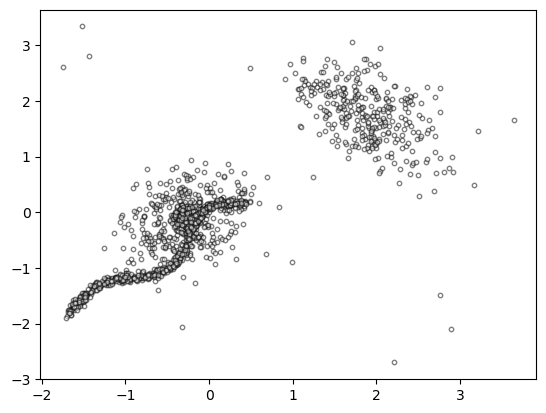

In [2]:
record = np.load('toy_cluster.npz')
Xs, y_true = record['X'], record['y']
X = np.load('toy_cluster.npz')['X']

plt.scatter(X[:, 0], X[:, 1], c='w', edgecolors='k', s=10, alpha=0.5)
plt.show()

Algorytm K-średnich (K-means)
-----------------------------
Na zmianę przypisujemy punkty do najbliższego środka i przesuwamy środek jako średnią przypisanych punktów.

![Krok 1](K_Means_Example_Step_1.png) ![Krok 2](K_Means_Example_Step_2.png) ![Krok 3](K_Means_Example_Step_3.png) ![Krok 4](K_Means_Example_Step_4.png)

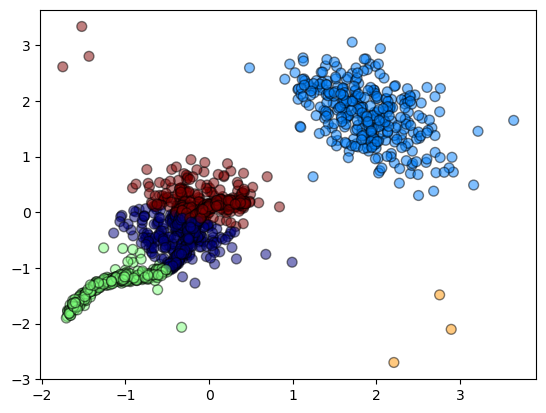

In [3]:
model = KMeans(n_clusters=5, n_init="auto", random_state=0)
labels = model.fit_predict(X)
colors = [plt.cm.jet(l / max(labels)) for l in labels]
plt.scatter(X[:, 0], X[:, 1], c=colors, edgecolors='k', s=50, alpha=0.5)
plt.show()

Prosty (=intuicyjny), sprawny, szybki (MiniBatchKMeans), przewidywalny.

Algorytm DBSCAN
---------------
O przynależności punktów decyduje liczba sąsiadów, punkty "rdzeniowe"/core (wiele punktów w pobliżu, A), "w oddali"/reachable (w kontakcie z "core", B/C) i szum/noise (izolowane od innych punktów).

![DBSCAN mechanika](DBSCAN-Illustration.png)

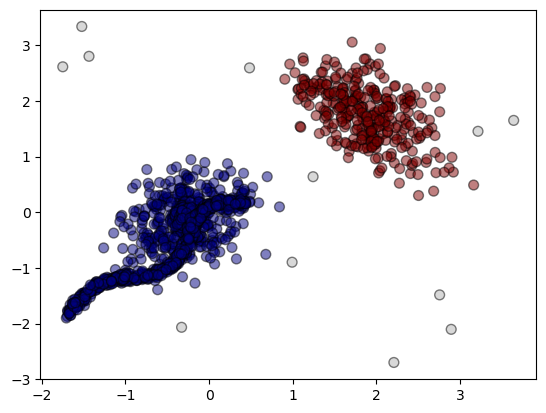

In [4]:
model = DBSCAN(eps=0.42, min_samples=8)
labels = model.fit_predict(X)
colors = [(0.7, 0.7, 0.7) if l < 0 else plt.cm.jet(l / max(labels)) \
          for l in labels]
plt.scatter(X[:, 0], X[:, 1], c=colors, edgecolors='k', s=50, alpha=0.5)
plt.show()

Skuteczny, nie wymaga szacowania liczby grup, osobno wyróżnia grupy i punkty odstające.

Algorytm grupowania hierarchicznego (hierarchical/agglomerative clustering)
-----------------------------------

Wersja z pojedynczym przyłączeniem (single linkage). Na początku każdy przykład jest osobną grupą, łączymy grupy według reguły - np. odległość dwóch najbliższych punktów w grupie.

![Idea grupowania hierarchicznego](Hierarchical_clustering_simple_diagram.png)

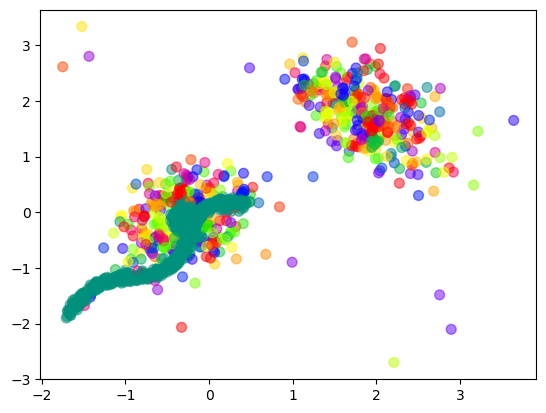

In [5]:
model = AgglomerativeClustering(n_clusters=350, linkage="single")
labels = model.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, alpha=0.5, cmap=plt.cm.prism)
plt.show()

Niewrażliwy na kształt/geometrię/rozplanowania grup, pozwala wyznaczyć hierarchię grup.

Algorytm mieszaniny rozkładów normalnych (Mixture of Gaussians)
---------------------------------------------------------------

Uogólnienie K-means, zamiast przypisania do najbliższego centroidu,
przyporządkowujemy do najbardziej prawdopodobnego modelu rozkładu normalnego.

![GMM 1](gmm_iter_01.png) ![GMM 10](gmm_iter_10.png) ![GMM 15](gmm_iter_15.png) ![GMM 20](gmm_iter_20.png) ![GMM 30](gmm_iter_30.png)

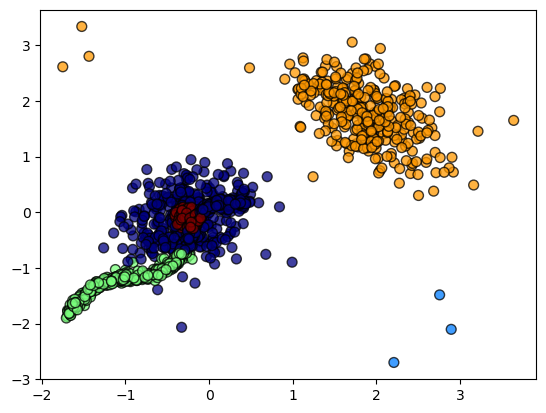

In [6]:
model = GaussianMixture(n_components=5, covariance_type="full", random_state=0)
labels = model.fit_predict(X)
colors = [plt.cm.jet_r(l / max(labels)) for l in labels]
plt.scatter(X[:, 0], X[:, 1], c=colors, edgecolors='k', s=50, alpha=0.75)
plt.show()

Odwzorowuje złożoną strukturę grup, prosty model.

Macierz kowariancji w różnych sytuacjach

![](nnomean_sm.jpg) ![](nmean_sm.jpg) ![](nsphe_sm.jpg) ![](ncov_sm.jpg) ![](nvar_sm.jpg)